# Preprocessing dan Ekstraksi Fitur

## Preprocessing: Menangani Missing Value Dan Outlier

### Deteksi Missing Value (Interpolasi linear)

Missing value adalah kondisi ketika terdapat nilai yang tidak tersedia atau kosong pada suatu dataset. Missing value biasanya ditandai dengan nilai `NaN`, `None`, atau sel kosong. Interpolasi linear merupakan metode yang digunakan untuk mengisi nilai yang hilang (missing value) dengan memperkirakan nilai tersebut berdasarkan nilai yang berada sebelum dan sesudah data yang kosong. Metode ini mengasumsikan bahwa perubahan nilai di antara dua titik data berlangsung secara linier atau bertahap.

Pada penelitian ini, missing value perlu diperiksa karena dapat memengaruhi hasil analisis dan visualisasi data. Data yang memiliki nilai kosong dapat menyebabkan proses perhitungan statistik, pembuatan grafik, maupun proses deteksi outlier menjadi kurang optimal.
Pada dataset kualitas udara, missing value dapat terjadi karena beberapa faktor, seperti data sensor yang tidak terekam, gangguan proses pengambilan data, atau adanya data yang tidak tersedia pada periode tertentu. Pada slide Data Understanding pada polutan CO yaitu sebanyak 76 data missing value. Dan disini kita akan menggunakan Interpolasi untuk menangani missing value.

In [1]:
import pandas as pd

# Membaca data
df = pd.read_csv("data/CO_lamongan.csv")

# Mengubah kolom CO menjadi numerik
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# Jika masih ada missing di awal/akhir, isi dengan nilai terdekat
df["CO"] = df["CO"].ffill()
df["CO"] = df["CO"].bfill()

# Mengisi missing value dengan interpolasi
df["CO"] = df["CO"].interpolate(method="linear")

df.to_csv("data/CO_lamongan_missing.csv", index=False)
print("File berhasil disimpan sebagai data/CO_lamongan_missing.csv")
print("\nMissing value setelah imputasi:")
print(df["CO"].isnull().sum())

File berhasil disimpan sebagai data/CO_lamongan_missing.csv

Missing value setelah imputasi:
0


### Deteksi Outlier (Metode Interquartile Range)

Interquartile Range (IQR) adalah metode statistik yang digunakan untuk mengukur penyebaran data pada bagian tengah distribusi dan dapat digunakan untuk mendeteksi outlier. IQR dihitung dari selisih antara kuartil ketiga (Q3) dan kuartil pertama (Q1). Pada penelitian kualitas udara, metode IQR digunakan untuk mengidentifikasi nilai konsentrasi CO yang menyimpang dari sebagian besar data. Nilai CO yang berada di luar batas IQR akan ditandai sebagai outlier dan kemudian dapat dianalisis lebih lanjut untuk mengetahui apakah nilai tersebut merupakan kesalahan data atau memang menunjukkan kondisi konsentrasi CO yang ekstrem.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("data/CO_lamongan_sorted.csv")
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# Menghitung Q1 dan Q3
Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Menentukan status data
df["status"] = df["CO"].apply(
    lambda x: "Outlier" if x < batas_bawah or x > batas_atas else "Normal"
)
outliers_iqr = df[df["status"] == "Outlier"]

print("Jumlah data:")
print(df["status"].value_counts())

print("\nData Outlier:")
print(df[df["status"] == "Outlier"][["date", "CO"]])

Jumlah data:
status
Normal     356
Outlier     10
Name: count, dtype: int64

Data Outlier:
           date        CO
44   2025-10-07  0.043492
46   2025-10-09  0.039035
103  2025-12-04  0.039578
104  2025-12-05  0.048821
105  2025-12-06  0.058064
106  2025-12-06  0.067307
114  2025-12-15  0.901257
126  2025-12-28  0.191613
161  2026-02-01  0.020215
358  2026-08-17  0.038314


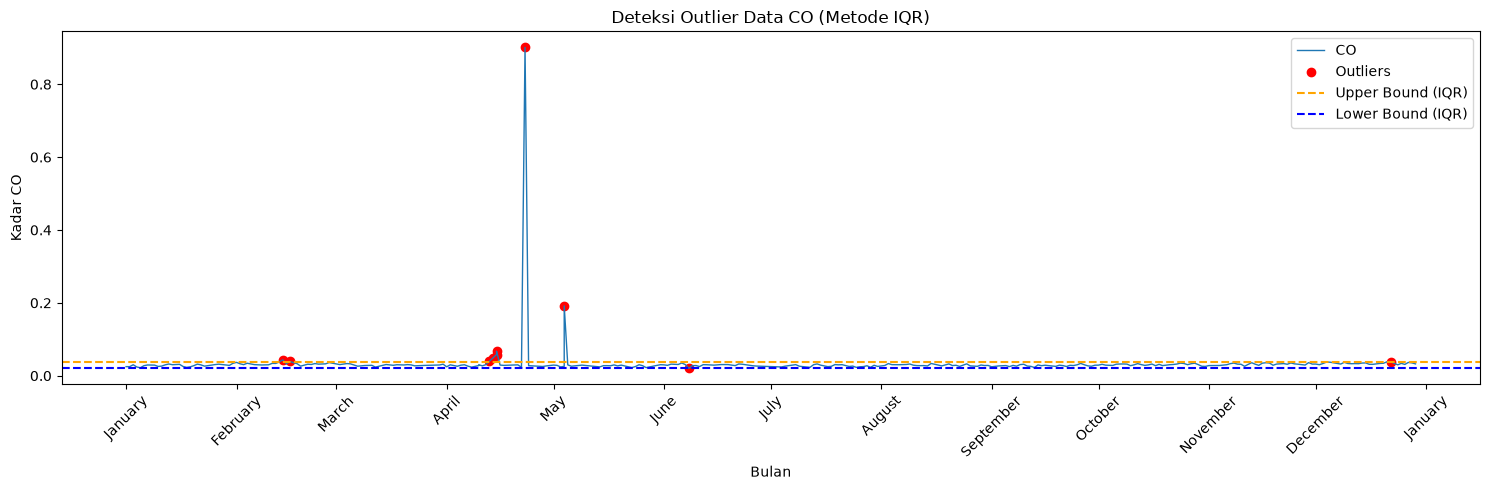

In [3]:
plt.figure(figsize=(15, 5))

# Grafik CO
plt.plot(df["date"], df["CO"], label="CO", linewidth=1)

# Titik outlier
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["CO"],
    color="red",
    marker="o",
    label="Outliers",
)

# Batas atas IQR
plt.axhline(batas_atas, color="orange", linestyle="dashed", label="Upper Bound (IQR)")

# Batas bawah IQR
plt.axhline(batas_bawah, color="blue", linestyle="dashed", label="Lower Bound (IQR)")

# Judul dan label
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Bulan")
plt.ylabel("Kadar CO")

# Menampilkan bulan pada sumbu X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Penanganan Outlier dan Interpolasi Data

Setelah mendeteksi keberadaan outlier, langkah selanjutnya adalah menandainya sebagai nilai kosong (NaN). Kemudian, metode interpolasi linier diterapkan pada keseluruhan dataset untuk mengisi nilai kosong (NaN) tersebut. Di akhir proses, teknik backward fill serta forward fill dimanfaatkan guna mengatasi nilai kosong pada bagian awalan atau akhiran rangkaian data yang tidak bisa diinterpolasi linier.

In [4]:
import pandas as pd

df = pd.read_csv("data/CO_lamongan_sorted.csv")
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# DETEKSI OUTLIER DENGAN IQR
Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Menentukan data outlier
outlier = (df["CO"] < batas_bawah) | (df["CO"] > batas_atas)

# Outlier diubah menjadi NaN
df.loc[outlier, "CO"] = None

# Mengisi nilai outlier dengan Linear Interpolation
df["CO"] = df["CO"].interpolate(method="linear")

# Menangani NaN jika berada di awal atau akhir data
df["CO"] = df["CO"].ffill().bfill()

df.to_csv("data/CO_lamongan_fix.csv", index=False)

print("File berhasil disimpan sebagai:")
print("data/CO_lamongan_fix.csv")

File berhasil disimpan sebagai:
data/CO_lamongan_fix.csv


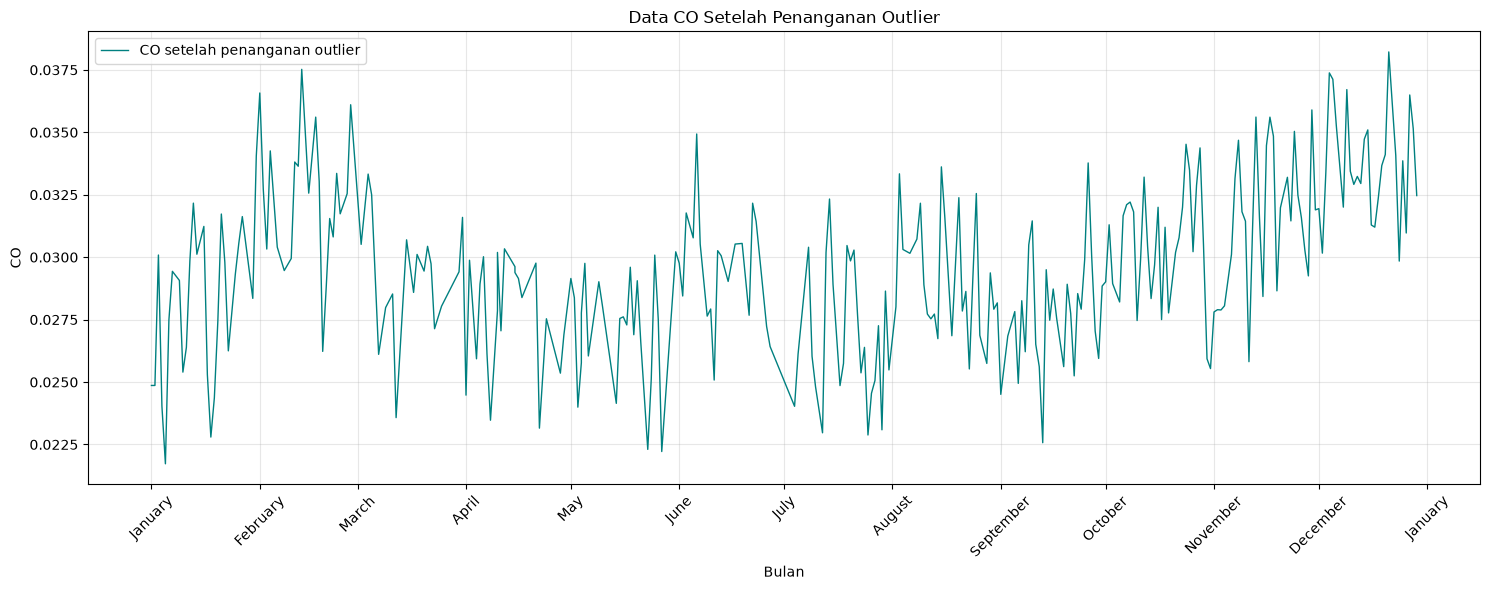

In [5]:
plt.figure(figsize=(15, 6))
plt.plot(df["date"], df["CO"], linewidth=1, color="teal", label="CO setelah penanganan outlier")

plt.title("Data CO Setelah Penanganan Outlier")
plt.xlabel("Bulan")
plt.ylabel("CO")

# Menampilkan nama bulan pada sumbu X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ekstraksi Fitur Time Series

Setelah data deret waktu polutan udara melalui tahap data cleaning, sehingga data yang digunakan sudah memiliki format yang sesuai, tidak terdapat nilai yang hilang, serta telah dilakukan penanganan terhadap outlier, tahap berikutnya adalah ekstraksi fitur time series. Tahap ini dilakukan untuk mengubah data deret waktu yang masih berupa rangkaian nilai pengamatan menjadi sekumpulan fitur numerik yang dapat menggambarkan karakteristik dan pola dari data tersebut.

Ekstraksi fitur diperlukan karena data deret waktu tidak hanya memiliki informasi berupa nilai polutan pada setiap waktu, tetapi juga memiliki karakteristik tertentu yang dapat digunakan untuk memahami pola datanya. Karakteristik tersebut dapat berupa nilai rata-rata, tingkat penyebaran data, perubahan nilai, hubungan antarwaktu, energi sinyal, maupun pola frekuensi. Dengan mengekstraksi karakteristik tersebut, informasi yang terdapat pada deret waktu dapat direpresentasikan dalam bentuk fitur yang lebih terstruktur dan dapat digunakan pada tahap analisis selanjutnya.

Dalam penelitian ini, proses ekstraksi fitur dilakukan menggunakan pustaka Python tsfel (Time Series Feature Extraction Library). TSFEL merupakan library yang menyediakan berbagai fungsi untuk menghitung fitur dari data deret waktu secara otomatis. Penggunaan TSFEL membantu mempercepat proses perhitungan serta menghasilkan fitur dengan metode yang lebih terstruktur dan konsisten.

Fitur yang diekstraksi dapat dikelompokkan ke dalam beberapa kategori utama, yaitu fitur statistik, temporal, dan spektral. Fitur statistik digunakan untuk menggambarkan karakteristik nilai pada data, seperti mean, median, standar deviasi, variansi, minimum, maksimum, skewness, kurtosis, dan RMS (Root Mean Square). Fitur temporal digunakan untuk melihat karakteristik perubahan sinyal dari waktu ke waktu, seperti autocorrelation, slope, mean difference, median difference, serta turning points. Sementara itu, fitur spektral digunakan untuk menganalisis karakteristik data berdasarkan domain frekuensi, seperti spectral centroid, spectral entropy, spectral spread, spectral skewness, spectral slope, dan spectral roll-off.

Pada proses ekstraksi, data konsentrasi polutan yang telah dibersihkan digunakan sebagai sinyal time series. Data tersebut kemudian diberikan kepada fungsi-fungsi fitur yang tersedia pada TSFEL. Setiap fungsi menghasilkan satu nilai yang merepresentasikan karakteristik tertentu dari keseluruhan sinyal. Seluruh hasil tersebut kemudian dikumpulkan menjadi sebuah tabel fitur, sehingga setiap kolom menunjukkan satu jenis fitur yang berhasil diekstraksi.

Hasil ekstraksi fitur kemudian disimpan dalam bentuk CSV sehingga dapat digunakan kembali untuk proses analisis dan pemodelan. Dengan demikian, data deret waktu polutan yang sebelumnya terdiri dari banyak pengamatan harian dapat direpresentasikan melalui sejumlah fitur numerik yang merangkum karakteristik penting dari data tersebut. Fitur-fitur tersebut selanjutnya dapat digunakan sebagai parameter input dalam proses machine learning maupun deep learning, atau sebagai dasar untuk melakukan analisis lebih lanjut terhadap pola dan karakteristik polutan udara. Dan disini kita akan ekstraksi fitur TSFEL sebanyak 68 fitur pada polutan CO:

In [6]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# Memuat data
df = pd.read_csv('data/CO_lamongan_fix.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
target_pollutant = 'CO'

# Pastikan data tipe numerik.
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# Inisialisasi 68 Daftar Fitur TSFEL
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

# Fungsi bantuan merubah output multivariat TSFEL menjadi float tunggal/skalar
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

# Pemanggilan fungsi TSFEL
def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Ekstraksi Fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang diekstrak pada {target_pollutant}: {extracted_features_final.shape[1]}")

# Export hasil ke folder data
extracted_features_final.to_csv('data/CO_Lamongan_TSFEL.csv', index=False)

Jumlah fitur yang diminta: 68


Berhasil! Jumlah fitur yang diekstrak pada CO: 68


In [7]:
df_tsfel = pd.read_csv("data/CO_Lamongan_TSFEL.csv")
df_tsfel.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.318271,10.702191,7.0,0.000872,188.261227,0.038219,0.029319,0.029231,0.021727,0.003158,...,0.131221,0.481339,0.000013,0.742701,0.001781,0.007379,2.13321,0.007139,0.000059,0.0


# Penjelasan Domain Fitur TSFEL

TSFEL (_Time Series Feature Extraction Library_) menyediakan berbagai fitur yang dapat digunakan untuk menggambarkan karakteristik suatu data deret waktu. Fitur-fitur tersebut dapat dikelompokkan berdasarkan sudut pandang analisisnya, yaitu **Statistical**, **Temporal**, dan **Spectral**.

Pembagian ini memungkinkan data deret waktu polutan dianalisis secara lebih menyeluruh. Domain statistik berfokus pada karakteristik nilai dan distribusi data, domain temporal melihat pola perubahan berdasarkan urutan waktu, sedangkan domain spektral mempelajari pola berdasarkan komponen frekuensinya.

## 1. Domain Statistical

Domain **Statistical** digunakan untuk memperoleh informasi mengenai karakteristik numerik dari kumpulan nilai dalam deret waktu. Analisis pada domain ini dapat memberikan gambaran mengenai pusat data, tingkat penyebaran, bentuk distribusi, serta besarnya variasi nilai polutan.

Beberapa fitur statistik yang digunakan antara lain:

- **`calc_max`**: Menghasilkan nilai paling tinggi yang terdapat pada sinyal polutan.
- **`calc_min`**: Menentukan nilai terendah dari keseluruhan data.
- **`calc_mean`**: Menghitung nilai rata-rata dari data polutan.
- **`calc_median`**: Menentukan nilai tengah setelah data diurutkan.
- **`calc_std`**: Mengukur seberapa jauh nilai data tersebar dari nilai rata-ratanya melalui standar deviasi.
- **`calc_var`**: Menunjukkan tingkat variasi data berdasarkan nilai varians.
- **`ecdf`**: Menggambarkan distribusi kumulatif empiris dari nilai-nilai pada deret waktu.
- **`ecdf_percentile`**: Menghasilkan informasi persentil berdasarkan distribusi kumulatif empiris.
- **`ecdf_percentile_count`**: Menghitung jumlah data yang berkaitan dengan posisi persentil tertentu pada ECDF.
- **`ecdf_slope`**: Menggambarkan perubahan atau kemiringan distribusi pada ECDF.
- **`hist_mode`**: Menentukan nilai yang paling sering muncul berdasarkan distribusi histogram.
- **`interq_range`**: Mengukur rentang 50% bagian tengah data menggunakan selisih antara kuartil ketiga dan kuartil pertama.
- **`kurtosis`**: Menggambarkan karakteristik bentuk distribusi, khususnya tingkat keruncingan atau ketebalan ekornya.
- **`skewness`**: Menunjukkan tingkat kemiringan distribusi data terhadap nilai pusatnya.
- **`mean_abs_deviation`**: Menghitung rata-rata jarak absolut setiap nilai terhadap nilai pusat.
- **`median_abs_deviation`**: Mengukur penyebaran data berdasarkan median sehingga relatif lebih tahan terhadap nilai ekstrem.
- **`rms`**: Menghitung _Root Mean Square_, yaitu ukuran besarnya nilai sinyal berdasarkan akar dari rata-rata kuadrat seluruh nilai.

## 2. Domain Temporal

Domain **Temporal** mempertimbangkan susunan nilai berdasarkan waktu. Berbeda dengan statistik yang lebih menitikberatkan pada distribusi nilai, fitur temporal digunakan untuk melihat bagaimana sinyal mengalami perubahan dari satu pengamatan ke pengamatan berikutnya.

Fitur yang termasuk dalam domain ini meliputi:

- **`abs_energy`**: Menghitung akumulasi kuadrat nilai sinyal sehingga dapat digunakan untuk menggambarkan besarnya energi keseluruhan sinyal.
- **`auc`**: Menghitung luas area yang terbentuk di bawah kurva deret waktu.
- **`autocorr`**: Mengukur hubungan antara nilai pada suatu waktu dengan nilai pada waktu sebelumnya.
- **`average_power`**: Menentukan besarnya daya rata-rata yang terdapat pada sinyal.
- **`calc_centroid`**: Menentukan posisi pusat massa atau titik keseimbangan sinyal pada dimensi waktunya.
- **`dfa`**: Menggunakan pendekatan _Detrended Fluctuation Analysis_ untuk mempelajari pola korelasi atau ketergantungan jangka panjang dalam deret waktu.
- **`distance`**: Mengukur panjang lintasan yang terbentuk dari perubahan posisi antar titik data secara berurutan.
- **`entropy`**: Menggambarkan tingkat ketidakpastian atau ketidakteraturan yang terdapat pada sinyal.
- **`higuchi_fractal_dimension`**: Mengestimasi dimensi fraktal menggunakan metode Higuchi untuk menggambarkan kompleksitas sinyal.
- **`petrosian_fractal_dimension`**: Mengukur kompleksitas sinyal berdasarkan perubahan atau jumlah variasi pada deret waktu menggunakan pendekatan Petrosian.
- **`hurst_exponent`**: Memberikan informasi mengenai karakteristik memori jangka panjang pada data dan kecenderungan suatu pola untuk berlanjut.
- **`lempel_ziv`**: Menggambarkan kompleksitas pola dalam sinyal berdasarkan struktur dan kemunculan pola yang dapat ditemukan.
- **`maximum_fractal_length`**: Mengukur panjang fraktal maksimum yang diperoleh dari analisis sinyal pada skala tertentu.
- **`mean_abs_diff`**: Menghitung rata-rata nilai absolut dari perubahan antar pengamatan yang berurutan.
- **`mean_diff`**: Menentukan rata-rata perubahan nilai antara satu titik waktu dengan titik waktu berikutnya.
- **`median_abs_diff`**: Menghasilkan median dari nilai perubahan absolut antar data yang berurutan.
- **`median_diff`**: Menghitung median perubahan nilai pada titik-titik waktu yang berdekatan.
- **`mse`**: Menghitung _Mean Squared Error_, yaitu rata-rata kuadrat kesalahan antara nilai sinyal dengan nilai pembanding atau estimasinya.
- **`negative_turning`**: Mengidentifikasi perubahan arah sinyal yang menunjukkan pergerakan dari kondisi meningkat menuju menurun.
- **`positive_turning`**: Mengidentifikasi perubahan arah sinyal dari kondisi menurun menuju meningkat.
- **`neighbourhood_peaks`**: Mendeteksi keberadaan titik puncak dengan mempertimbangkan nilai-nilai di sekitar titik tersebut.
- **`pk_pk_distance`**: Mengukur selisih antara nilai puncak tertinggi dan lembah terendah pada sinyal.
- **`slope`**: Menunjukkan kecenderungan arah perubahan sinyal secara keseluruhan melalui kemiringan garis regresi.
- **`sum_abs_diff`**: Menjumlahkan seluruh perubahan absolut yang terjadi antar titik data secara berurutan.
- **`zero_cross`**: Menghitung jumlah kejadian ketika sinyal melewati atau memotong nilai nol sebagai titik referensi.

## 3. Domain Spectral

Domain **Spectral** menganalisis sinyal berdasarkan komponen frekuensi yang terkandung di dalamnya. Pendekatan ini berguna untuk menemukan pola berulang, dominasi frekuensi tertentu, distribusi energi, serta karakteristik perubahan sinyal yang tidak selalu terlihat apabila hanya diamati berdasarkan nilai waktunya.

Fitur-fitur yang digunakan dalam domain ini antara lain:

- **`fundamental_frequency`**: Menentukan frekuensi dasar yang menjadi komponen utama dalam sinyal.
- **`max_frequency`**: Menunjukkan frekuensi tertinggi yang teridentifikasi dalam hasil analisis spektrum.
- **`median_frequency`**: Menentukan titik frekuensi yang membagi distribusi energi spektrum menjadi dua bagian yang relatif seimbang.
- **`human_range_energy`**: Mengukur energi sinyal pada rentang frekuensi tertentu yang didefinisikan dalam TSFEL.
- **`lpcc`**: Menghasilkan _Linear Prediction Cepstral Coefficients_, yaitu representasi karakteristik spektral yang berasal dari pendekatan prediksi linear.
- **`mfcc`**: Menghasilkan _Mel-Frequency Cepstral Coefficients_ untuk merepresentasikan karakteristik spektrum menggunakan skala Mel.
- **`max_power_spectrum`**: Menentukan nilai daya terbesar yang muncul pada spektrum frekuensi.
- **`power_bandwidth`**: Menggambarkan lebar rentang frekuensi yang mengandung sebagian besar energi sinyal.
- **`spectral_centroid`**: Menentukan titik pusat distribusi energi pada spektrum frekuensi.
- **`spectral_decrease`**: Mengukur kecenderungan penurunan magnitudo spektrum ketika frekuensi meningkat.
- **`spectral_distance`**: Mengukur perbedaan antara karakteristik spektrum pada bagian-bagian yang dianalisis.
- **`spectral_entropy`**: Menilai tingkat penyebaran atau ketidakaturan distribusi energi pada spektrum.
- **`spectral_kurtosis`**: Menggambarkan bentuk distribusi spektrum berdasarkan karakteristik keruncingannya.
- **`spectral_positive_turning`**: Mengidentifikasi perubahan arah positif pada karakteristik spektral.
- **`spectral_roll_off`**: Menentukan frekuensi batas ketika sebagian besar energi spektrum telah tercapai.
- **`spectral_roll_on`**: Menentukan posisi awal frekuensi ketika energi spektrum mulai mencapai bagian tertentu dari total energinya.
- **`spectral_skewness`**: Menggambarkan tingkat kemiringan distribusi energi pada spektrum frekuensi.
- **`spectral_slope`**: Mengukur kecenderungan naik atau turunnya magnitudo spektrum terhadap perubahan frekuensi.
- **`spectral_spread`**: Menunjukkan tingkat penyebaran energi frekuensi terhadap posisi _spectral centroid_.
- **`spectral_variation`**: Menggambarkan perubahan karakteristik spektrum dari satu bagian analisis ke bagian lainnya.
- **`spectrogram_mean_coeff`**: Menghasilkan nilai rata-rata koefisien yang diperoleh dari representasi spektrogram.
- **`wavelet_abs_mean`**: Menghitung rata-rata nilai absolut dari koefisien yang diperoleh melalui analisis wavelet.
- **`wavelet_energy`**: Mengukur energi yang terdapat pada koefisien wavelet.
- **`wavelet_entropy`**: Menggambarkan tingkat ketidakaturan distribusi energi pada koefisien wavelet.
- **`wavelet_std`**: Menghitung standar deviasi dari koefisien wavelet.
- **`wavelet_var`**: Menghitung varians dari koefisien wavelet.